In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression


In [2]:
df=pd.read_csv('UK_Accident.csv')

In [3]:
df.head()

,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


In [4]:
df.isnull().sum().sum()

np.int64(3655911)

In [5]:
df.columns

Index(['Unnamed: 0', 'Accident_Index', 'Location_Easting_OSGR',
       'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force',
       'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties',
       'Date', 'Day_of_Week', 'Time', 'Local_Authority_(District)',
       'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number',
       'Road_Type', 'Speed_limit', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Year'],
      dtype='str')

In [6]:
df.drop([ 'Unnamed: 0',
    'Accident_Index',
    'Location_Easting_OSGR',
    'Location_Northing_OSGR',
    'LSOA_of_Accident_Location',
    'Local_Authority_(Highway)'],axis=1,inplace=True)

In [7]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_(District),...,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year
0,-0.191170,51.489096,1,2,1,1,04/01/2005,3,17:42,12,...,None within 50 metres,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,2005
1,-0.211708,51.520075,1,3,1,1,05/01/2005,4,17:36,12,...,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005
2,-0.206458,51.525301,1,3,2,1,06/01/2005,5,00:15,12,...,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005
3,-0.173862,51.482442,1,3,1,1,07/01/2005,6,10:35,12,...,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,2005
4,-0.156618,51.495752,1,3,1,1,10/01/2005,2,21:13,12,...,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,2005


In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [9]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

In [10]:
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [11]:
df['Carriageway_Hazards'].isnull().sum()

np.int64(1476900)

In [12]:
df.drop('Number_of_Casualties',axis=1,inplace=True)

In [13]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,...,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,...,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,2005,1,4
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,...,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,5
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,...,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,6
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,...,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,7
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,...,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,2005,1,10


In [14]:
df['Road_Type'].value_counts()
df['Road_Type'].isnull().sum()


np.int64(0)

In [15]:
df.isnull().sum().sum()

np.int64(3547455)

In [16]:
df = df.dropna(subset=['Longitude'])


In [17]:
df['Light_Conditions'] = df['Light_Conditions'].replace({
    'Daylight: Street light present': 'Daylight',
    'Darkness: Street lights present and lit': 'Darkness_Lit',
    'Darkness: No street lighting': 'Darkness_No_Light',
    'Darkness: Street lighting unknown': 'Darkness_Unknown',
    'Darkness: Street lights present but unlit': 'Darkness_Unlit'
})

In [18]:
df.isnull().sum()

Longitude                                            0
Latitude                                             0
Police_Force                                         0
Accident_Severity                                    0
Number_of_Vehicles                                   0
Day_of_Week                                          0
Local_Authority_(District)                           0
1st_Road_Class                                       0
1st_Road_Number                                      0
Road_Type                                            0
Speed_limit                                          0
Junction_Control                                602769
2nd_Road_Class                                       0
2nd_Road_Number                                      0
Pedestrian_Crossing-Human_Control                   17
Pedestrian_Crossing-Physical_Facilities             33
Light_Conditions                                     0
Weather_Conditions                                   0
Road_Surfa

In [19]:
df['Carriageway_Hazards'].dtype

<StringDtype(storage='python', na_value=nan)>

In [20]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,...,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,...,Daylight,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,2005,1,4
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,...,Darkness_Lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,5
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,...,Darkness_Lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,6
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,...,Daylight,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,7
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,...,Darkness_Unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,2005,1,10


In [21]:
X=df.drop(['Accident_Severity'],axis=1)
y=df['Accident_Severity']

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [23]:
from sklearn.impute import SimpleImputer

In [24]:
impute=SimpleImputer(strategy='constant',fill_value='Missing')
X_train[['Junction_Control']]=impute.fit_transform(X_train[['Junction_Control']])
X_test[['Junction_Control']]=impute.transform(X_test[['Junction_Control']])

In [25]:
X_train[['Special_Conditions_at_Site']]=impute.fit_transform(X_train[['Special_Conditions_at_Site']])
X_test[['Special_Conditions_at_Site']]=impute.transform(X_test[['Special_Conditions_at_Site']])

In [26]:

X_train[['Carriageway_Hazards']]=impute.fit_transform(X_train[['Carriageway_Hazards']])
X_test[['Carriageway_Hazards']]=impute.transform(X_test[['Carriageway_Hazards']])

In [27]:
X_train[['Pedestrian_Crossing-Physical_Facilities']]=impute.fit_transform(X_train[['Pedestrian_Crossing-Physical_Facilities']])
X_test[['Pedestrian_Crossing-Physical_Facilities']]=impute.transform(X_test[['Pedestrian_Crossing-Physical_Facilities']])

In [28]:
df['Pedestrian_Crossing-Physical_Facilities'].value_counts()

Pedestrian_Crossing-Physical_Facilities
No physical crossing within 50 meters          1252479
Pedestrian phase at traffic signal junction     100244
non-junction pedestrian crossing                 79229
Zebra crossing                                   40106
Central refuge                                   27658
Footbridge or subway                              4300
Name: count, dtype: int64

In [29]:
from sklearn.preprocessing import OneHotEncoder

In [30]:
from sklearn.preprocessing import OneHotEncoder

# Create encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore',dtype=int)

# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Pedestrian_Crossing-Human_Control']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Pedestrian_Crossing-Human_Control']),
    index=X_train.index
)

X_train = X_train.drop('Pedestrian_Crossing-Human_Control', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Pedestrian_Crossing-Human_Control']])

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Pedestrian_Crossing-Human_Control']),
    index=X_test.index
)

X_test = X_test.drop('Pedestrian_Crossing-Human_Control', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)


In [31]:
X_train

,Longitude,Latitude,Police_Force,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,...,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day,Pedestrian_Crossing-Human_Control_Control by other authorised person,Pedestrian_Crossing-Human_Control_Control by school crossing patrol,Pedestrian_Crossing-Human_Control_None within 50 metres,Pedestrian_Crossing-Human_Control_nan
1396983,-2.355085,53.294161,7,2,6,129,3,537,Roundabout,60,...,Missing,1,Yes,2014,5,23,0,0,1,0
546706,-2.191575,51.293739,54,2,5,634,3,36,Single carriageway,30,...,Missing,2,Yes,2007,11,8,0,0,1,0
95739,-1.261481,52.368727,23,2,5,292,6,3394,Single carriageway,30,...,Missing,1,Yes,2005,12,15,0,0,1,0
465264,-2.172492,52.430783,21,2,1,254,3,451,Single carriageway,60,...,Missing,2,Yes,2007,2,4,0,0,1,0
316660,0.425399,51.695510,42,1,6,454,3,414,Roundabout,70,...,Missing,2,Yes,2006,3,3,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259252,-1.512972,53.806881,13,2,5,204,6,0,Single carriageway,30,...,Missing,1,No,2006,7,6,0,0,1,0
1414515,-0.434380,53.847181,16,1,4,231,6,0,Single carriageway,30,...,Missing,1,No,2014,2,19,0,0,1,0
131963,-0.740945,52.078681,43,5,7,479,1,1,Dual carriageway,70,...,Missing,2,Yes,2005,8,27,0,0,1,0
671256,-0.506170,51.744953,41,1,5,431,3,41,Dual carriageway,70,...,Missing,2,Yes,2009,7,23,0,0,1,0


In [32]:
df['Light_Conditions'].value_counts()

Light_Conditions
Daylight                         1102144
Darkness_Lit                      296329
Darkeness: No street lighting      82552
Darkness_Unknown                   16116
Darkness_Unlit                      6908
Name: count, dtype: int64

In [33]:
# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Light_Conditions']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Light_Conditions']),
    index=X_train.index
)

X_train = X_train.drop('Light_Conditions', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Light_Conditions']])

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Light_Conditions']),
    index=X_test.index
)

X_test = X_test.drop('Light_Conditions', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

In [34]:
# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Weather_Conditions']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Weather_Conditions']),
    index=X_train.index
)

X_train = X_train.drop('Weather_Conditions', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Weather_Conditions']])

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Weather_Conditions']),
    index=X_test.index
)

X_test = X_test.drop('Weather_Conditions', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

In [35]:
X_train

,Longitude,Latitude,Police_Force,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,...,Light_Conditions_Daylight,Weather_Conditions_Fine with high winds,Weather_Conditions_Fine without high winds,Weather_Conditions_Fog or mist,Weather_Conditions_Other,Weather_Conditions_Raining with high winds,Weather_Conditions_Raining without high winds,Weather_Conditions_Snowing with high winds,Weather_Conditions_Snowing without high winds,Weather_Conditions_Unknown
1396983,-2.355085,53.294161,7,2,6,129,3,537,Roundabout,60,...,1,0,0,0,0,0,1,0,0,0
546706,-2.191575,51.293739,54,2,5,634,3,36,Single carriageway,30,...,1,0,1,0,0,0,0,0,0,0
95739,-1.261481,52.368727,23,2,5,292,6,3394,Single carriageway,30,...,1,0,1,0,0,0,0,0,0,0
465264,-2.172492,52.430783,21,2,1,254,3,451,Single carriageway,60,...,1,0,1,0,0,0,0,0,0,0
316660,0.425399,51.695510,42,1,6,454,3,414,Roundabout,70,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259252,-1.512972,53.806881,13,2,5,204,6,0,Single carriageway,30,...,1,0,1,0,0,0,0,0,0,0
1414515,-0.434380,53.847181,16,1,4,231,6,0,Single carriageway,30,...,1,0,1,0,0,0,0,0,0,0
131963,-0.740945,52.078681,43,5,7,479,1,1,Dual carriageway,70,...,1,0,1,0,0,0,0,0,0,0
671256,-0.506170,51.744953,41,1,5,431,3,41,Dual carriageway,70,...,1,0,0,0,0,0,1,0,0,0


In [36]:

# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Road_Surface_Conditions']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Road_Surface_Conditions']),
    index=X_train.index
)

X_train = X_train.drop('Road_Surface_Conditions', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Road_Surface_Conditions']])

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Road_Surface_Conditions']),
    index=X_test.index
)

X_test = X_test.drop('Road_Surface_Conditions', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

In [37]:
df['Special_Conditions_at_Site'].value_counts()

Special_Conditions_at_Site
Roadworks                                          17220
Ol or diesel                                        5243
Mud                                                 4609
Road surface defective                              3664
Auto traffic singal out                             2788
Permanent sign or marking defective or obscured     2269
Auto traffic signal partly defective                 785
Name: count, dtype: int64

In [38]:

# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Special_Conditions_at_Site']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Special_Conditions_at_Site']),
    index=X_train.index
)

X_train = X_train.drop('Special_Conditions_at_Site', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Special_Conditions_at_Site']])

test_encoded = pd.DataFrame(
     test_encoded,
     columns=ohe.get_feature_names_out(['Special_Conditions_at_Site']),
     index=X_test.index
)

X_test = X_test.drop('Special_Conditions_at_Site', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

In [39]:
X_train.isnull().sum()

Longitude                                                                     0
Latitude                                                                      0
Police_Force                                                                  0
Number_of_Vehicles                                                            0
Day_of_Week                                                                   0
Local_Authority_(District)                                                    0
1st_Road_Class                                                                0
1st_Road_Number                                                               0
Road_Type                                                                     0
Speed_limit                                                                   0
Junction_Control                                                              0
2nd_Road_Class                                                                0
2nd_Road_Number                         

In [40]:
df.isnull().sum()

Longitude                                            0
Latitude                                             0
Police_Force                                         0
Accident_Severity                                    0
Number_of_Vehicles                                   0
Day_of_Week                                          0
Local_Authority_(District)                           0
1st_Road_Class                                       0
1st_Road_Number                                      0
Road_Type                                            0
Speed_limit                                          0
Junction_Control                                602769
2nd_Road_Class                                       0
2nd_Road_Number                                      0
Pedestrian_Crossing-Human_Control                   17
Pedestrian_Crossing-Physical_Facilities             33
Light_Conditions                                     0
Weather_Conditions                                   0
Road_Surfa

In [41]:
X_train

,Longitude,Latitude,Police_Force,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,...,Road_Surface_Conditions_Snow,Road_Surface_Conditions_Wet/Damp,Special_Conditions_at_Site_Auto traffic signal partly defective,Special_Conditions_at_Site_Auto traffic singal out,Special_Conditions_at_Site_Missing,Special_Conditions_at_Site_Mud,Special_Conditions_at_Site_Ol or diesel,Special_Conditions_at_Site_Permanent sign or marking defective or obscured,Special_Conditions_at_Site_Road surface defective,Special_Conditions_at_Site_Roadworks
1396983,-2.355085,53.294161,7,2,6,129,3,537,Roundabout,60,...,0,1,0,0,1,0,0,0,0,0
546706,-2.191575,51.293739,54,2,5,634,3,36,Single carriageway,30,...,0,0,0,0,1,0,0,0,0,0
95739,-1.261481,52.368727,23,2,5,292,6,3394,Single carriageway,30,...,0,0,0,0,1,0,0,0,0,0
465264,-2.172492,52.430783,21,2,1,254,3,451,Single carriageway,60,...,0,0,0,0,1,0,0,0,0,0
316660,0.425399,51.695510,42,1,6,454,3,414,Roundabout,70,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259252,-1.512972,53.806881,13,2,5,204,6,0,Single carriageway,30,...,0,0,0,0,1,0,0,0,0,0
1414515,-0.434380,53.847181,16,1,4,231,6,0,Single carriageway,30,...,0,0,0,0,1,0,0,0,0,0
131963,-0.740945,52.078681,43,5,7,479,1,1,Dual carriageway,70,...,0,0,0,0,1,0,0,0,0,0
671256,-0.506170,51.744953,41,1,5,431,3,41,Dual carriageway,70,...,0,1,0,0,1,0,0,0,0,0


In [42]:
X_train[['Junction_Control']]=impute.fit_transform(X_train[['Junction_Control']])
X_test[['Junction_Control']]=impute.transform(X_test[['Junction_Control']])

In [43]:


# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Junction_Control']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Junction_Control']),
    index=X_train.index
)

X_train = X_train.drop('Junction_Control', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Junction_Control']])

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Junction_Control']),
    index=X_test.index
)

X_test = X_test.drop('Junction_Control', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)


In [44]:
X_train

,Longitude,Latitude,Police_Force,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,...,Special_Conditions_at_Site_Mud,Special_Conditions_at_Site_Ol or diesel,Special_Conditions_at_Site_Permanent sign or marking defective or obscured,Special_Conditions_at_Site_Road surface defective,Special_Conditions_at_Site_Roadworks,Junction_Control_Authorised person,Junction_Control_Automatic traffic signal,Junction_Control_Giveway or uncontrolled,Junction_Control_Missing,Junction_Control_Stop Sign
1396983,-2.355085,53.294161,7,2,6,129,3,537,Roundabout,60,...,0,0,0,0,0,0,0,1,0,0
546706,-2.191575,51.293739,54,2,5,634,3,36,Single carriageway,30,...,0,0,0,0,0,0,0,1,0,0
95739,-1.261481,52.368727,23,2,5,292,6,3394,Single carriageway,30,...,0,0,0,0,0,0,0,0,1,0
465264,-2.172492,52.430783,21,2,1,254,3,451,Single carriageway,60,...,0,0,0,0,0,0,0,1,0,0
316660,0.425399,51.695510,42,1,6,454,3,414,Roundabout,70,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259252,-1.512972,53.806881,13,2,5,204,6,0,Single carriageway,30,...,0,0,0,0,0,0,0,1,0,0
1414515,-0.434380,53.847181,16,1,4,231,6,0,Single carriageway,30,...,0,0,0,0,0,0,0,0,1,0
131963,-0.740945,52.078681,43,5,7,479,1,1,Dual carriageway,70,...,0,0,0,0,0,0,0,0,1,0
671256,-0.506170,51.744953,41,1,5,431,3,41,Dual carriageway,70,...,0,0,0,0,0,0,0,0,1,0


In [45]:
df['Carriageway_Hazards'].value_counts()


Carriageway_Hazards
Other object in carriageway                11760
Any animal (except a ridden horse)          8014
Pedestrian in carriageway (not injured)     3585
Involvement with previous accident          2282
Dislodged vehicle load in carriageway       1606
Name: count, dtype: int64

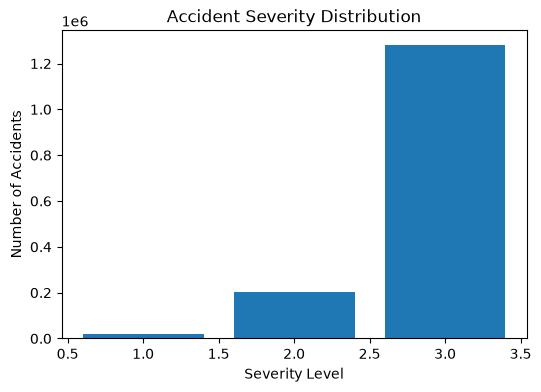

In [46]:
import matplotlib.pyplot as plt

severity_counts = df['Accident_Severity'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(severity_counts.index, severity_counts.values)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")

plt.show()

In [47]:


# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Did_Police_Officer_Attend_Scene_of_Accident']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Did_Police_Officer_Attend_Scene_of_Accident']),
    index=X_train.index
)

X_train = X_train.drop('Did_Police_Officer_Attend_Scene_of_Accident', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Did_Police_Officer_Attend_Scene_of_Accident']])

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Did_Police_Officer_Attend_Scene_of_Accident']),
    index=X_test.index
)

X_test = X_test.drop('Did_Police_Officer_Attend_Scene_of_Accident', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)


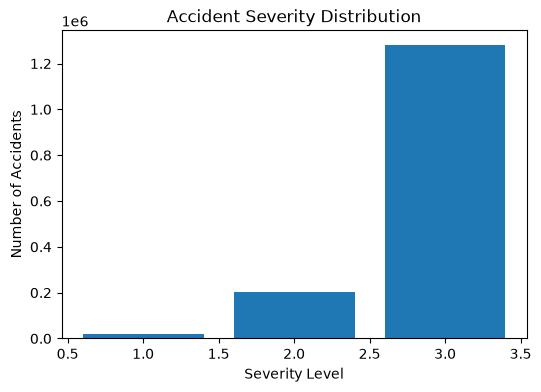

In [48]:
import matplotlib.pyplot as plt

severity_counts = df['Accident_Severity'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(severity_counts.index, severity_counts.values)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")

plt.show()

<Axes: >

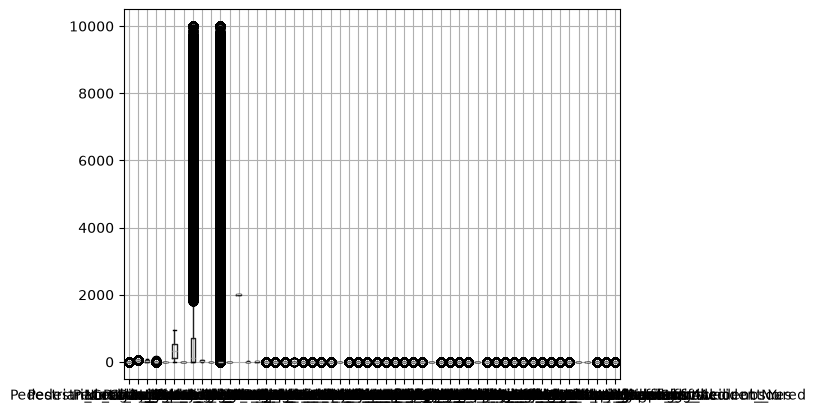

In [49]:
X_train.boxplot()

In [50]:

# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Carriageway_Hazards']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Carriageway_Hazards']),
    index=X_train.index
)

X_train = X_train.drop('Carriageway_Hazards', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Carriageway_Hazards']])

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Carriageway_Hazards']),
    index=X_test.index
)

X_test = X_test.drop('Carriageway_Hazards', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

In [51]:

# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Pedestrian_Crossing-Physical_Facilities']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Pedestrian_Crossing-Physical_Facilities']),
    index=X_train.index
)

X_train = X_train.drop('Pedestrian_Crossing-Physical_Facilities', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Pedestrian_Crossing-Physical_Facilities']])

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Pedestrian_Crossing-Physical_Facilities']),
    index=X_test.index
)

X_test = X_test.drop('Pedestrian_Crossing-Physical_Facilities', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

In [52]:

# ---------------- X_train ----------------
train_encoded = ohe.fit_transform(X_train[['Road_Type']])

train_encoded = pd.DataFrame(
    train_encoded,
    columns=ohe.get_feature_names_out(['Road_Type']),
    index=X_train.index
)

X_train = X_train.drop('Road_Type', axis=1)
X_train = pd.concat([X_train, train_encoded], axis=1)

# ---------------- X_test ----------------
test_encoded = ohe.transform(X_test[['Road_Type']])

test_encoded = pd.DataFrame(
    test_encoded,
    columns=ohe.get_feature_names_out(['Road_Type']),
    index=X_test.index
)

X_test = X_test.drop('Road_Type', axis=1)
X_test = pd.concat([X_test, test_encoded], axis=1)

In [53]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train,y_train)



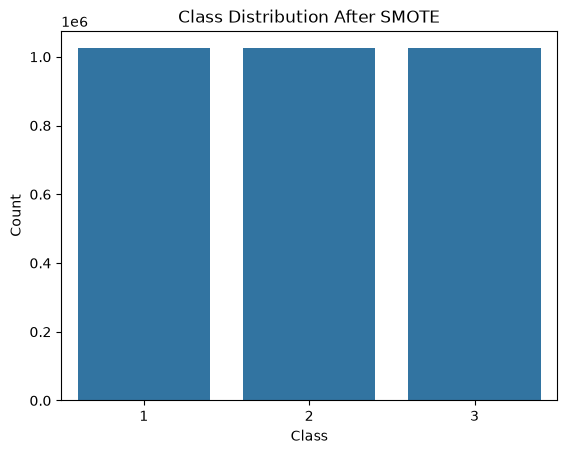

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train_resampled)

plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [55]:
import pandas as pd

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Accident_Severity
3    1280120
2     204488
1      19441
Name: count, dtype: int64

After SMOTE:
Accident_Severity
3    1024175
2    1024175
1    1024175
Name: count, dtype: int64


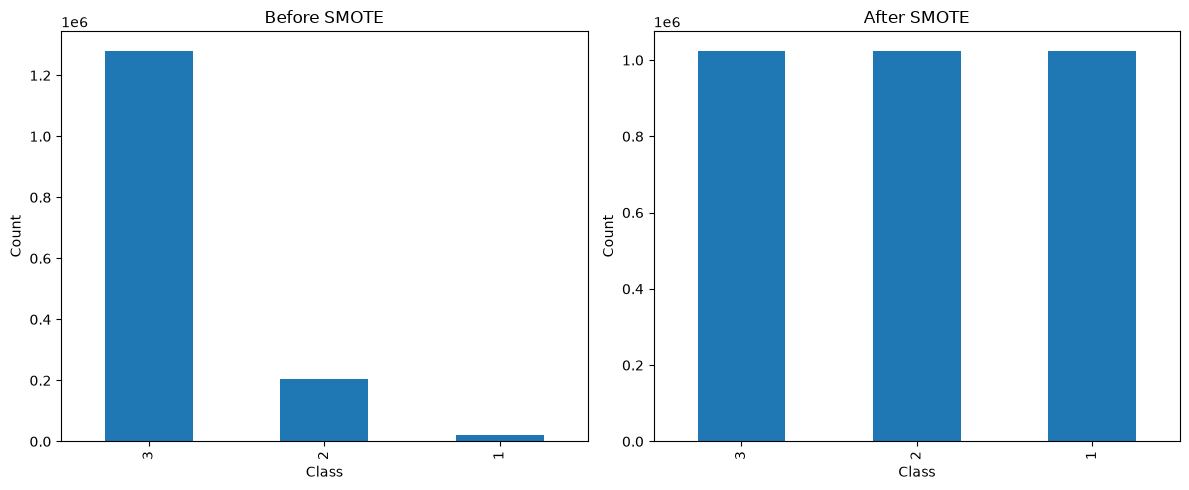

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y.value_counts().plot(kind='bar', ax=axes[0], title='Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

y_train_resampled.value_counts().plot(kind='bar', ax=axes[1], title='After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [57]:
print(y_train_resampled.value_counts())

Accident_Severity
3    1024175
2    1024175
1    1024175
Name: count, dtype: int64


In [58]:
dtc=DecisionTreeClassifier(class_weight='balanced')

In [59]:
dtc.fit(X_train_resampled,y_train_resampled)

,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But

In [60]:
y_pred=dtc.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score,recall_score,f1_score,confusion_matrix

In [62]:
accuracy_score(y_test,y_pred)

0.736700907549616

In [63]:
print(y_train_resampled.shape)
print(y_test.shape)
print(y_pred.shape)

(3072525,)
(300810,)
(300810,)


In [64]:
confusion_matrix(y_test,y_pred)

array([[   335,    915,   2590],
       [  1203,  10526,  29296],
       [  4584,  40615, 210746]])